In [51]:
import kagglehub
import os
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image, ImageTk
from random import sample
import seaborn as sns
import tkinter as tk
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, AveragePooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Загрузка данных

In [30]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "balabaskar/tom-and-jerry-image-classification"
)

print("Dataset path:", path)

Dataset path: data/kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3


# Подготовка выборок

In [31]:
def load_images_from_folders(tom_path, jerry_path):
    images = []
    labels = []

    for file in os.listdir(jerry_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(jerry_path, file)
            image = Image.open(img_path).convert('RGB')
            image = image.resize((128, 128))
            image_array = np.array(image) / 255.0
            images.append(image_array)
            labels.append(0)

    for file in os.listdir(tom_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(tom_path, file)
            image = Image.open(img_path).convert('RGB')
            image = image.resize((128, 128))
            image_array = np.array(image) / 255.0
            images.append(image_array)
            labels.append(1)

    return np.array(images), np.array(labels)


tom_path = r"data\kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3\tom_and_jerry\tom_and_jerry\tom"
jerry_path = r"data\kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3\tom_and_jerry\tom_and_jerry\jerry"

X, Y = load_images_from_folders(tom_path, jerry_path)

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(sss.split(X, Y))

x_train, x_test = X[train_idx], X[test_idx]
y_train, y_test = Y[train_idx].astype(np.float32), Y[test_idx].astype(np.float32)

In [32]:
print(x_train.shape)
print(x_test.shape)

(2536, 128, 128, 3)
(634, 128, 128, 3)


# Проверка сбалансированности классов

In [33]:
def check_class_balance(labels, name):
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        class_name = "Jerry (0)" if u == 0 else "Tom (1)"
        percent = (c / len(labels)) * 100
        print(f"{class_name}: {c} images ({percent:.2f}%)")

check_class_balance(y_train, "Train set")
check_class_balance(y_test, "Test set")


Train set distribution:
Jerry (0): 992 images (39.12%)
Tom (1): 1544 images (60.88%)

Test set distribution:
Jerry (0): 248 images (39.12%)
Tom (1): 386 images (60.88%)


# Max poolling

In [34]:
# описание модели
model_max = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [35]:
# сборка модели
model_max.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# обучение модели
model_max.fit(x_train, y_train, batch_size=16,
          epochs=5,
          validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.6625 - loss: 0.6148 - val_accuracy: 0.7666 - val_loss: 0.4641
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8328 - loss: 0.4088 - val_accuracy: 0.8912 - val_loss: 0.2892
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9062 - loss: 0.2431 - val_accuracy: 0.9132 - val_loss: 0.2420
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9235 - loss: 0.1988 - val_accuracy: 0.9416 - val_loss: 0.1884
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9444 - loss: 0.1411 - val_accuracy: 0.9543 - val_loss: 0.1419


In [40]:
# проверка модели на тестовых данных
predictions_max = model_max.predict(x_test)
binary_predictions_max = (predictions_max > 0.5).astype(int).flatten()
accuracy_max = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_max * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Точность предсказания на тестовых данных : 95.42587%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.93      0.96      0.94       248
         Том       0.97      0.95      0.96       386

    accuracy                           0.95       634
   macro avg       0.95      0.95      0.95       634
weighted avg       0.95      0.95      0.95       634



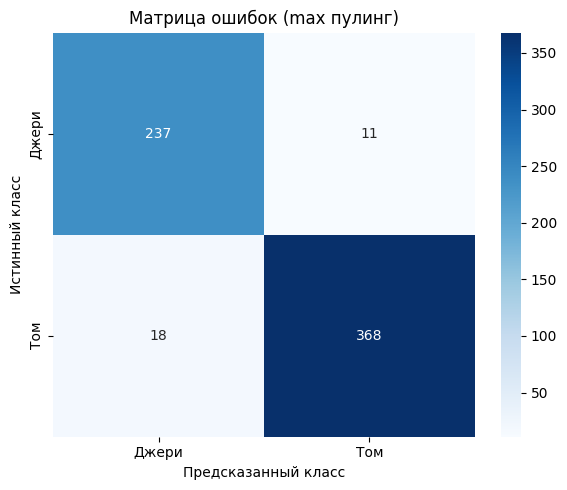

In [56]:
cm_max = confusion_matrix(y_test, binary_predictions_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_max,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Average Pooling

In [41]:
# описание модели
model_avg = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [42]:
# сборка модели
model_avg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# обучение модели
model_avg.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6483 - loss: 0.6371 - val_accuracy: 0.7366 - val_loss: 0.5447
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7291 - loss: 0.5581 - val_accuracy: 0.7366 - val_loss: 0.5267
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.7697 - loss: 0.4796 - val_accuracy: 0.7950 - val_loss: 0.4759
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8190 - loss: 0.4013 - val_accuracy: 0.8691 - val_loss: 0.3303
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8509 - loss: 0.3536 - val_accuracy: 0.8628 - val_loss: 0.3187


In [43]:
# проверка модели на тестовых данных
predictions_avg = model_avg.predict(x_test)
binary_predictions_avg = (predictions_avg > 0.5).astype(int).flatten()
accuracy_avg = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_avg * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Точность предсказания на тестовых данных : 95.42587%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.89      0.75      0.81       248
         Том       0.85      0.94      0.89       386

    accuracy                           0.86       634
   macro avg       0.87      0.84      0.85       634
weighted avg       0.86      0.86      0.86       634



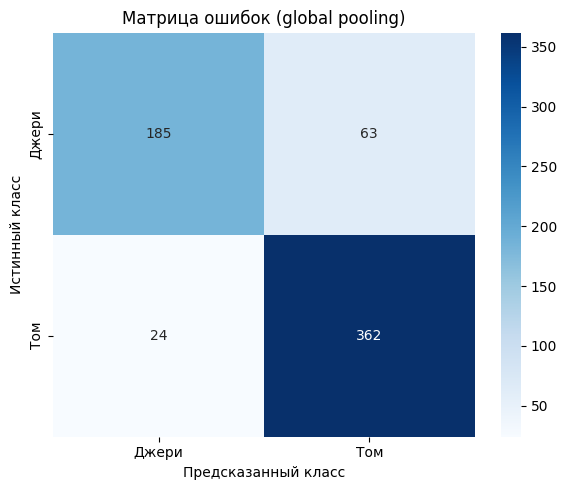

In [57]:
cm_avg = confusion_matrix(y_test, binary_predictions_avg)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_avg,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_avg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global pooling)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Global Average Pooling

In [47]:
# описание модели
model_global_avg = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [48]:
# сборка модели
model_global_avg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# обучение модели
model_global_avg.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6092 - loss: 0.6555 - val_accuracy: 0.6530 - val_loss: 0.6653
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6581 - loss: 0.6262 - val_accuracy: 0.5615 - val_loss: 0.6684
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7397 - loss: 0.5288 - val_accuracy: 0.8612 - val_loss: 0.3944
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8261 - loss: 0.4113 - val_accuracy: 0.8864 - val_loss: 0.3045
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8778 - loss: 0.3131 - val_accuracy: 0.9101 - val_loss: 0.2738


In [49]:
# проверка модели на тестовых данных
predictions_global_avg = model_global_avg.predict(x_test)
binary_predictions_global_avg = (predictions_global_avg > 0.5).astype(int).flatten()
accuracy_global_avg = np.mean(y_test == binary_predictions_global_avg)
print(f'Точность предсказания на тестовых данных : {accuracy_global_avg * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Точность предсказания на тестовых данных : 91.00946%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.93      0.83      0.88       248
         Том       0.90      0.96      0.93       386

    accuracy                           0.91       634
   macro avg       0.91      0.90      0.90       634
weighted avg       0.91      0.91      0.91       634



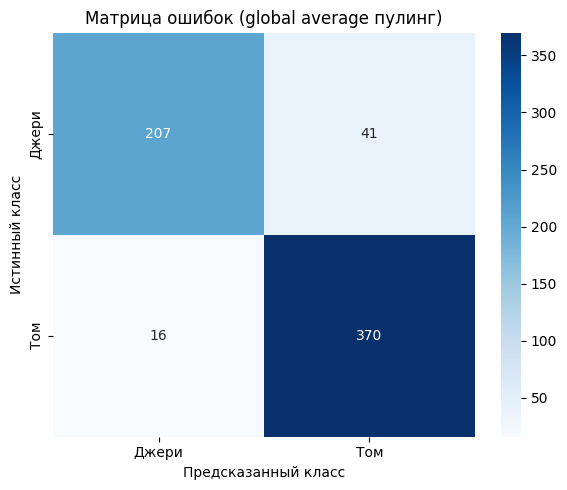

In [58]:
cm_global_avg = confusion_matrix(y_test, binary_predictions_global_avg)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_global_avg,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_global_avg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global average пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Global Max Pooling

In [52]:
# описание модели
model_global_max = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalMaxPooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [53]:
# сборка модели
model_global_max.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# обучение модели
model_global_max.fit(x_train, y_train, batch_size=16,
                     epochs=5,
                     validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6128 - loss: 0.6543 - val_accuracy: 0.6893 - val_loss: 0.5990
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8021 - loss: 0.4296 - val_accuracy: 0.9069 - val_loss: 0.2802
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8987 - loss: 0.2693 - val_accuracy: 0.9290 - val_loss: 0.2084
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9318 - loss: 0.1880 - val_accuracy: 0.9274 - val_loss: 0.1859
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9503 - loss: 0.1309 - val_accuracy: 0.8076 - val_loss: 0.5160


In [54]:
# проверка модели на тестовых данных
predictions_global_max = model_global_max.predict(x_test)
binary_predictions_global_max = (predictions_global_max > 0.5).astype(int).flatten()
accuracy_global_max = np.mean(y_test == binary_predictions_global_max)
print(f'Точность предсказания на тестовых данных : {accuracy_global_max * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Точность предсказания на тестовых данных : 80.75710%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.98      0.52      0.68       248
         Том       0.76      0.99      0.86       386

    accuracy                           0.81       634
   macro avg       0.87      0.76      0.77       634
weighted avg       0.85      0.81      0.79       634



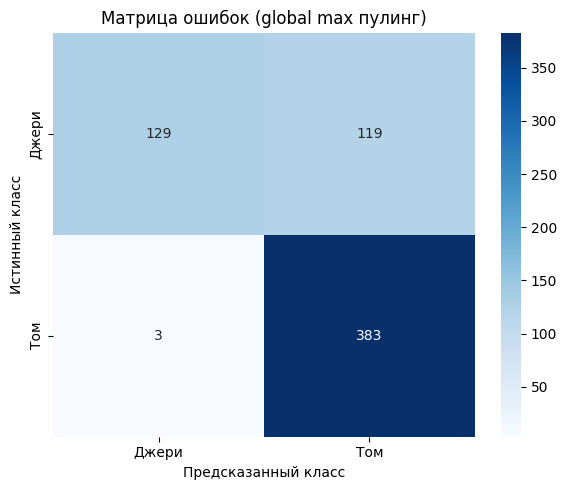

In [59]:
cm_global_max = confusion_matrix(y_test, binary_predictions_global_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_global_max,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_global_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Mixed Pooling

In [61]:
# описание модели
model_mixed = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [62]:
# сборка модели
model_mixed.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# обучение модели
model_mixed.fit(x_train, y_train, batch_size=16,
                     epochs=5,
                     validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.6459 - loss: 0.6399 - val_accuracy: 0.7397 - val_loss: 0.5253
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.7642 - loss: 0.4946 - val_accuracy: 0.8612 - val_loss: 0.3692
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8612 - loss: 0.3235 - val_accuracy: 0.9085 - val_loss: 0.2440
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9176 - loss: 0.2173 - val_accuracy: 0.8833 - val_loss: 0.3064
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9255 - loss: 0.1916 - val_accuracy: 0.9211 - val_loss: 0.1953


In [63]:
# проверка модели на тестовых данных
predictions_mixed = model_mixed.predict(x_test)
binary_predictions_mixed = (predictions_mixed > 0.5).astype(int).flatten()
accuracy_mixed = np.mean(y_test == binary_predictions_mixed)
print(f'Точность предсказания на тестовых данных : {accuracy_mixed * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Точность предсказания на тестовых данных : 92.11356%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.94      0.85      0.89       248
         Том       0.91      0.97      0.94       386

    accuracy                           0.92       634
   macro avg       0.93      0.91      0.92       634
weighted avg       0.92      0.92      0.92       634



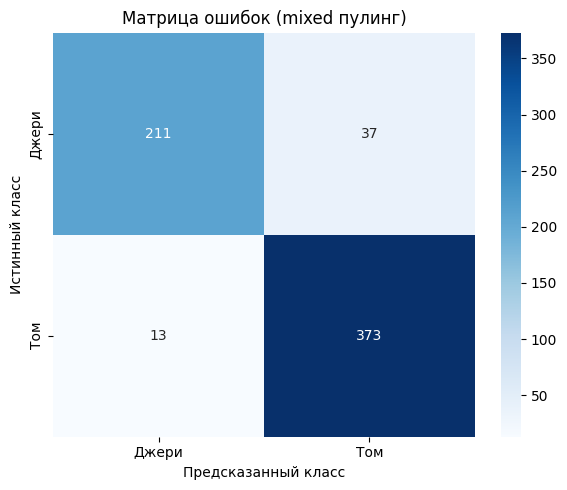

In [64]:
cm_mixed = confusion_matrix(y_test, binary_predictions_mixed)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_mixed,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mixed,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (mixed пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Количество параметров

In [66]:
print("Max Pooling")
model_max.summary()
print("Average Pooling")
model_avg.summary()
print("Global Average Pooling")
model_global_avg.summary()
print("Global Max Pooling")
model_global_max.summary()
print("Mixed Pooling")
model_mixed.summary()

Max Pooling


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,097,029 (19.44 MB)

 Trainable params: 1,699,009 (6.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 30, 30, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,097,029 (19.44 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,398,020 (12.96 MB)

In [65]:
window = tk.Tk()
window.title("Примеры предсказаний")

# выбираем 9 случайных изображений
img_indxs = sample(range(len(x_test)), 9)

labels = ["Джери", "Том"]

photos = []

for i, idx in enumerate(img_indxs):
    img = x_test[idx]
    img = (img * 255.0).clip(0, 255).astype(np.uint8)

    pil_image = Image.fromarray(img)
    photo = ImageTk.PhotoImage(image=pil_image)
    photos.append(photo)
    pred = (model_max.predict(np.expand_dims(x_test[idx], axis=0)) > 0.5).astype(int).flatten()[0]

    true_label = labels[int(y_test[idx])]
    pred_label = labels[int(pred)]
    label = tk.Label(
        window,
        image=photo,
        text=f"Истинный класс: {true_label}\nПредсказанный класс: {pred_label}",
        compound="top"
    )
    row = i // 3
    col = i % 3
    label.grid(row=row, column=col, padx=10, pady=10)

window.mainloop()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
